# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

# ANSWERS
1. A model is linear when the output is a straight linear combination of the coefficients. The model is linear in paramters and coefficients (the beta values)
2. A dummy variable coefficient tells us how much higher or lower the outcome is compared to the reference group.  Dummy Variables for categorical data can also describe if the outcome of the observation is true or false. The intercept of the model is represented by the reference group itself, so the intercept shows the predicted outcome when ALL dummy values are 0, meaning the outcome is the reference group itself.Positive means above and negative means below the reference group's value.
3. Technically linear regression can be used for classification if the feature being predicted is converted to binary and that may be used, however, this is not ideal at all. It makes the least logical sense to use linear regression for something like this, rather, one should use logistic regression.
4. Using too many variables within the model and if the training error is much less than the test error.
5. Multicolinearity occurs when two or more independent variables are highlighy correlated with each other which makes it difficult to isolate the individual effect of each variable. This leads to unstable and unreliable coefficients. The two-stage least squares technique addresses this by finding a middle "instrumental" variable which is correlated with one x but not the error. Then, regress the problematic x  onto the instrumt and use that fitted value onward which cleans the coefficient estimates and allows for cleaner outputs.
6. You can add polynomial terms such as X^2, X^3, and so on as extra features. You can also perform log transformation to compress skewed relationships. Lastly, you can multiply two varibales togetherto capture combined effects (seen later in the assignment)
7. The slope coefficient in linear regression is the value that for every one unit increase in x, the y value changes that many units holding all else constant.
8. Train/Test splits randomly split the data and train the model on the training set (typically 80% of the data) and evaluate on the test set (remaining 20%). K-fold cross validation splits the data into subsets and trains on k-1 folds and tests on the remaining 1. This repeats k times and the average results are recorded across all k runs.
9. k values typically should be selected to balance bias and variance. A smaller k value leads to higher bias but lower variance whereas a larger k value has a lower bias with higher variance.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [1]:
import numpy as np 
import pandas as pd 
df = pd.read_csv('./data/Q1_clean.csv')
df.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [2]:
print(df.columns.tolist())

['Price', 'Review Scores Rating', 'Neighbourhood ', 'Property Type', 'Room Type']


In [3]:
#1
df.columns = df.columns.str.strip()
most_expensive_borough = df.groupby('Neighbourhood')['Price'].mean()
print(most_expensive_borough)
print("Most expensive borough:", most_expensive_borough.idxmax())
print("Average price:", most_expensive_borough.max())

Neighbourhood
Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
Name: Price, dtype: float64
Most expensive borough: Manhattan
Average price: 183.6642863215166


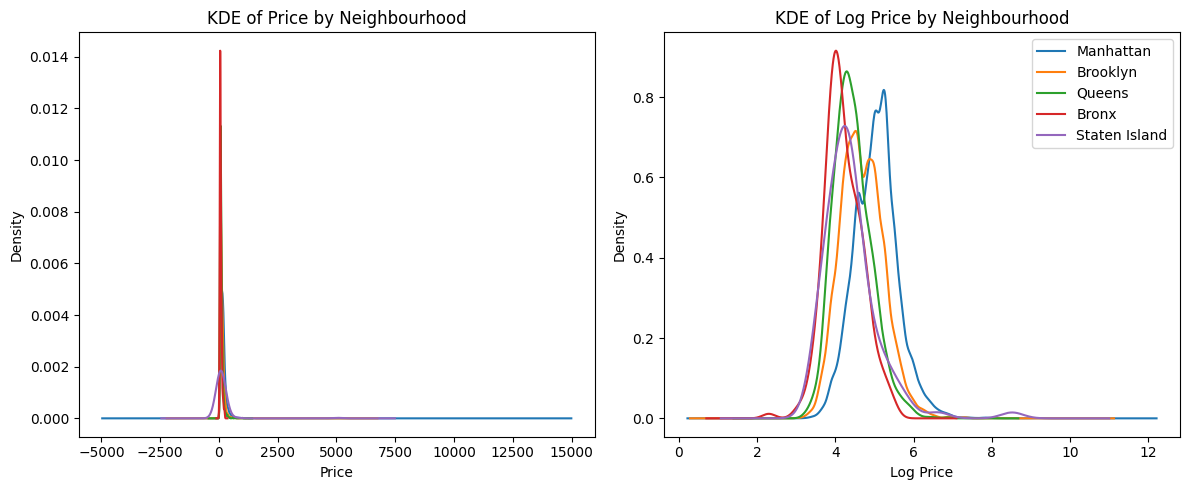

In [4]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for neighbourhood in df['Neighbourhood'].unique():
    subset = df[df['Neighbourhood'] == neighbourhood]['Price']
    subset.plot.kde(ax=axes[0], label=neighbourhood)
    np.log(subset).plot.kde(ax=axes[1], label=neighbourhood)

axes[0].set_title('KDE of Price by Neighbourhood')
axes[1].set_title('KDE of Log Price by Neighbourhood')
axes[0].set_xlabel('Price')
axes[1].set_xlabel('Log Price')
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
#2
from sklearn.linear_model import LinearRegression
dummies = pd.get_dummies(df['Neighbourhood'], drop_first=True)
X = dummies
y = df['Price']
model = LinearRegression()
model.fit(X, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
print("Intercept:", model.intercept_)
print("Coefficients:", dict(zip(dummies.columns, model.coef_)))
print("\nGroup Means:")
print(most_expensive_borough)

Intercept: 75.27649769585331
Coefficients: {'Brooklyn': np.float64(52.470880647495), 'Manhattan': np.float64(108.38778862566352), 'Queens': np.float64(21.580735008549482), 'Staten Island': np.float64(70.89016897081363)}

Group Means:
Neighbourhood
Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
Name: Price, dtype: float64


I did drop the first category (Bronx) as it was the intercept. The mean value (75.276498) is the intercept value since it is themean price of the Bronx. Each coefficient outputted representes how much mroe expensive that neighborhood is compared to the Bronx (all outputs were positive, so nothing was cheaper). If you were to add the coefficient to the intercept value for each neighborhood, you would end up with the exact mean per group from Q1, showing that the conditional groupmeans and estimated coefficients are directly related.

In [7]:
#3
review_scores_rating = df[['Review Scores Rating']]
model_2 = LinearRegression()
model_2.fit(review_scores_rating, y)
print("Intercept:", model_2.intercept_)
print("Coefficient for Review Scores Rating (Slope):", model_2.coef_[0])

Intercept: 60.878390657123546
Coefficient for Review Scores Rating (Slope): 1.0208266022674763


In [8]:
#4
dummies_q4 = pd.get_dummies(df['Neighbourhood'], drop_first=True)
X_q4 = pd.concat([dummies_q4, df['Review Scores Rating']], axis=1)

model_q4 = LinearRegression()
model_q4.fit(X_q4, y)

coef_df = pd.DataFrame({'Coefficient': model_q4.coef_}, index=X_q4.columns)
print("Intercept:", model_q4.intercept_)
print(coef_df)

Intercept: -23.812561011672244
                      Coefficient
Brooklyn                51.704240
Manhattan              108.228737
Queens                  21.694600
Staten Island           71.766552
Review Scores Rating     1.081116


Interpretation: For every one point increase/decrease in Review Scores Rating, the price increases/decreases by $1.02 on average. For example, a one unit increase in Review Scores Rating could be associated with a $1.02 increase in average nightly charge, and vice versa if there was a one point decrease. The intercept of $60.88 represents the predicted price when the Review Scores Rating is 0.

In [9]:
#5
def fit_model(g):
    model = LinearRegression()
    model.fit(g[['Review Scores Rating']], g['Price'])
    return pd.Series({'Intercept': model.intercept_, 'Slope': model.coef_[0]})

results = df.groupby('Neighbourhood').apply(fit_model)
print(results)

                 Intercept      Slope
Neighbourhood                        
Bronx            22.638385   0.574311
Brooklyn          6.245395   1.315476
Manhattan        63.953814   1.304014
Queens           50.898086   0.502017
Staten Island  2985.709425 -31.257437


/tmp/ipykernel_1536/2205577580.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results = df.groupby('Neighbourhood').apply(fit_model)


The slopes vary considerably across neighborhoods. Bronx and Queens have relatively small, positive slopes, Brooklyn and Manhattan have larger positive slopes, and Staten Island has a dramatic negative slope which could be caused due to a small sample size. This information suggests thaat the relationship between Review Scores Rating and Price is not consistent across neighborhoods.

In [10]:
#6
from sklearn.model_selection import cross_val_score

interactions = dummies_q4.multiply(df['Review Scores Rating'], axis=0)
X_q5 = pd.concat([dummies_q4, df[['Review Scores Rating']], interactions], axis=1)

scores3 = cross_val_score(LinearRegression(), review_scores_rating, y, cv=5, scoring='neg_root_mean_squared_error')
scores4 = cross_val_score(LinearRegression(), X_q4, y, cv=5, scoring='neg_root_mean_squared_error')
scores5 = cross_val_score(LinearRegression(), X_q5, y, cv=5, scoring='neg_root_mean_squared_error')

results_cv = pd.DataFrame({
    'Model 3 (Rating only)': [-scores3.mean()],
    'Model 4 (Neighbourhood + Rating)': [-scores4.mean()],
    'Model 5 (Separate slopes)': [-scores5.mean()]
})
print(results_cv)

   Model 3 (Rating only)  Model 4 (Neighbourhood + Rating)  \
0             146.320595                        142.826481   

   Model 5 (Separate slopes)  
0                 143.860862  


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [11]:
df2 = pd.read_csv('/workspace/scratchpad/data/cars_hw.csv')
df2.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [12]:
#1
# Summarizing Price
import matplotlib.pyplot as plt
print(df2['Price'].describe())

count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


In [13]:
# Summarize Price by Body_Type
print(df2.groupby('Body_Type')['Price'].describe())

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


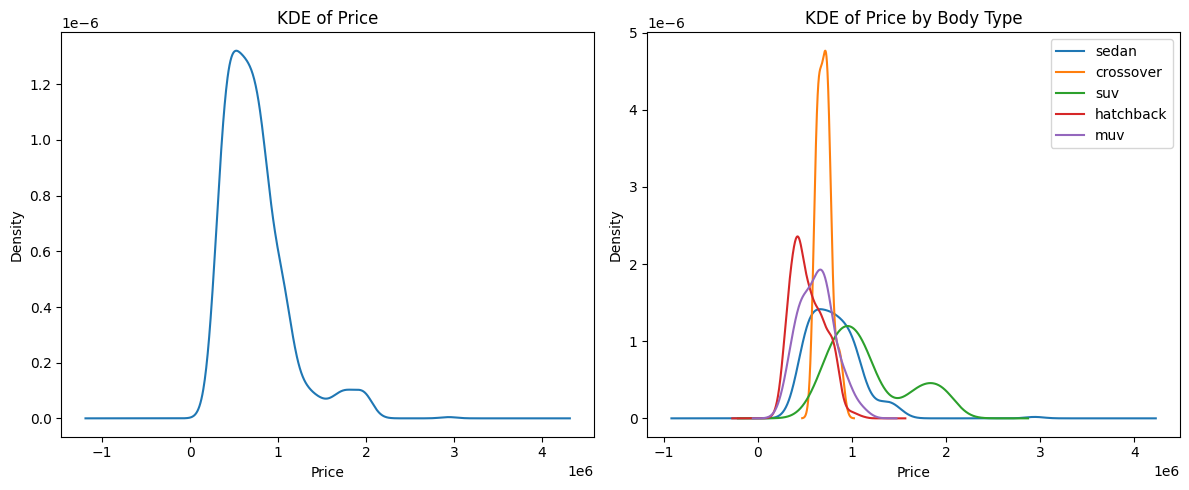

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# KDE of just price
df2['Price'].plot.kde(ax=axes[0])
axes[0].set_title('KDE of Price')
axes[0].set_xlabel('Price')

# Grouped KDE by Body_Type
for body in df2['Body_Type'].unique():
    df2[df2['Body_Type'] == body]['Price'].plot.kde(ax=axes[1], label=body)

axes[1].set_title('KDE of Price by Body Type')
axes[1].set_xlabel('Price')
axes[1].legend()

plt.tight_layout()
plt.show()

The most expensive cars are SUVs and the cars with the most variance are Sedans.

In [15]:
#2
from sklearn.linear_model import LinearRegression
X_seat = df2[['Seating_Capacity']]
y2 = df2['Price']

model_seat = LinearRegression()
model_seat.fit(X_seat, y2)

print("Intercept:", model_seat.intercept_)
print("Slope:", model_seat.coef_[0])

Intercept: 439032.0141018266
Slope: 59267.99803672175


Interpretation: For every one additional seat, the price increases by 59267 Indian Rupees, and vice versa if we work backwards. THe price would drop 59267 Indian Rupees if a car has one less seat than the reference car.

In [16]:
dummies_seat = pd.get_dummies(df2['Seating_Capacity'], drop_first=True)
model_seat_cat = LinearRegression()
model_seat_cat.fit(dummies_seat, y2)

coef_df2 = pd.DataFrame({'Coefficient': model_seat_cat.coef_}, index=dummies_seat.columns)
coef_df2['Coefficient'] = coef_df2['Coefficient'].map('{:,.0f}'.format) # AI generated code to help me convert the numbers from scientific notation to raw numbers
print("Intercept:", model_seat_cat.intercept_)
print(coef_df2)

Intercept: 188000.00000000314
  Coefficient
5     546,484
6   1,456,000
7     735,949
8     271,800


No, the differences are not linear. If they were, each additional seat would add rouhgly the same price. The price jumps disproportionately from five to six seats and then decreases significantly from seven to eight seats.

In [17]:
#3
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

df2['Age'] = 2026 - df2['Make_Year']

results = {}
for degree in range(1, 8):
    pipe = Pipeline([('poly', PolynomialFeatures(degree=degree)), ('model', LinearRegression())])
    scores = cross_val_score(pipe, df2[['Age']], y2, cv=10, scoring='neg_root_mean_squared_error')
    results[degree] = -scores.mean()

best_degree = pd.Series(results, name='RMSE').idxmin()
print(pd.Series(results, name='RMSE'))

1    307576.542574
2    308059.750331
3    307440.790990
4    307881.112096
5    307742.220358
6    308128.065477
7    307251.173145
Name: RMSE, dtype: float64


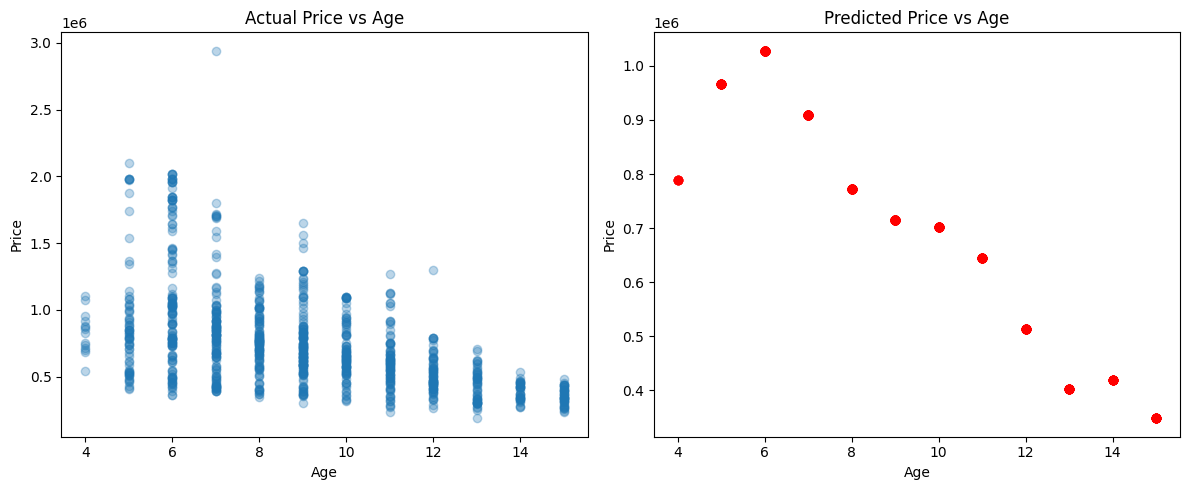

In [18]:
#4
pipe_best = Pipeline([('poly', PolynomialFeatures(degree=best_degree)), ('model', LinearRegression())])
pipe_best.fit(df2[['Age']], y2)

# Generate predicted prices
df2['Predicted_Price'] = pipe_best.predict(df2[['Age']])

# Plot actual vs predicted
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1 (Actual Price vs Age)
axes[0].scatter(df2['Age'], y2, alpha=0.3)
axes[0].set_title('Actual Price vs Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Price')

# Plot 2 (Predicted Price vs Age)
axes[1].scatter(df2['Age'], df2['Predicted_Price'], alpha=0.3, color='red')
axes[1].set_title('Predicted Price vs Age')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Price')

plt.tight_layout()
plt.show()

The model partially captures the general trend of the data showing a consistent decrease in price as age increases. However, the model does not accurately fit all the patterns in the data. The actual prices show a wide spread each age value whereas the predicted values are a single smooth curve. The model captures the general trend of a decreasing price as age increases, but misses high variability when compared to the actual prices. This suggests that age alone is not sufficient to fully predict the price of a car.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [19]:
df3 = pd.read_csv('/workspace/scratchpad/data/heart_hw.csv')
df3.head()

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0


In [20]:
#1 (a) and (b)
# Proportion of surviving patients in each group
proportions = df3.groupby('transplant')['y'].mean()
print(proportions)

transplant
control      0.117647
treatment    0.347826
Name: y, dtype: float64


In [21]:
ATE = proportions['treatment'] - proportions['control']
print("ATE:", ATE)

ATE: 0.23017902813299232


In [22]:
#2
# Need to encode transplant as 0/1 first
df3['transplant_dummy'] = (df3['transplant'] == 'treatment').astype(int)

X_transplant = df3[['transplant_dummy']]
y3 = df3['y']

model_transplant = LinearRegression()
model_transplant.fit(X_transplant, y3)

print("Intercept:", model_transplant.intercept_)
print("Transplant coefficient:", model_transplant.coef_[0])

Intercept: 0.1176470588235293
Transplant coefficient: 0.23017902813299249


The Intercept computed is equal to the control group proportion from Q1 and the Transplant Coefficient is equal to the Average Treatment Effect (ATE) value.

In [23]:
#3
X3 = df3[['transplant_dummy', 'age']]
model_q4 = LinearRegression()
model_q4.fit(X3, y3)

print("Intercept:", model_q4.intercept_)
print("Transplant coefficient:", model_q4.coef_[0])
print("Age coefficient:", model_q4.coef_[1])

Intercept: 0.7019569721740947
Transplant coefficient: 0.2647016865036751
Age coefficient: -0.013607217160218647


/usr/local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


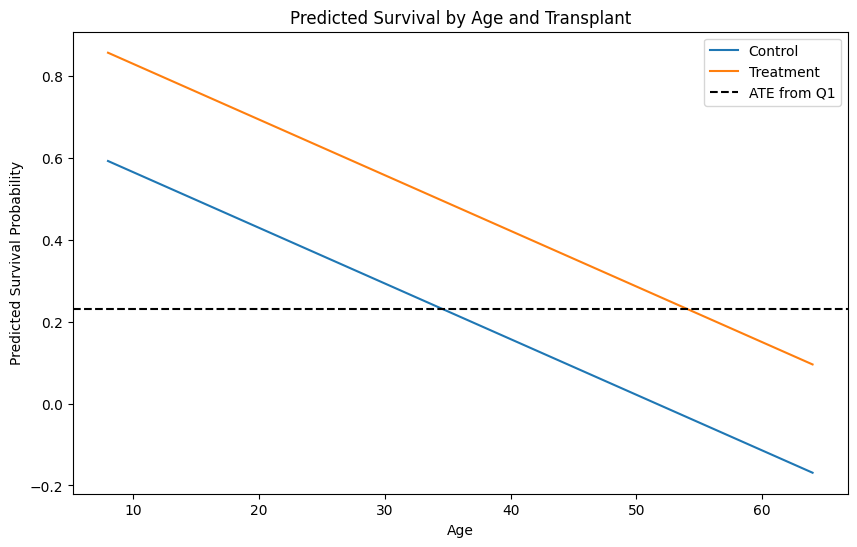

In [24]:
age_range = np.linspace(df3['age'].min(), df3['age'].max(), 100)


pred_control = model_q4.predict(np.column_stack([np.zeros(100), age_range]))
pred_treatment = model_q4.predict(np.column_stack([np.ones(100), age_range]))

plt.figure(figsize=(10, 6))
plt.plot(age_range, pred_control, label='Control')
plt.plot(age_range, pred_treatment, label='Treatment')
plt.axhline(y=ATE, color='black', linestyle='--', label='ATE from Q1')
plt.xlabel('Age')
plt.ylabel('Predicted Survival Probability')
plt.title('Predicted Survival by Age and Transplant')
plt.legend()
plt.show()

The transplant coefficient increased slightly from part two when controlling for age which suggests that once we account for age differences between groups, the estimated benefit of a transplanted heart is a bit larger. The intercept represents the predicted probability of a control patient (no transplant) at age 0. Althought his is not possible, it is where the regression line begins. The transplant coefficient is the estimated increase in survival probability from receiving a heart transplant if we hold age constant. The age coefficient represents that for each additional year of age, the predicted survival probability decreases by about 1.36 percentage points if we hold the transplant status constant. Because the treatment and control lines are paralell and the gap between them is ~.2647 which is larger than the ATE value of ~.2302, therefore the ATE under-estimates the transplant benefit at every age.



Intercept: 0.35486517529945855
Transplant coefficient: 0.9077513885685898
Age coefficient: -0.0055242575069736986
Transplant*Age coefficient: -0.01459063825685528


/usr/local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


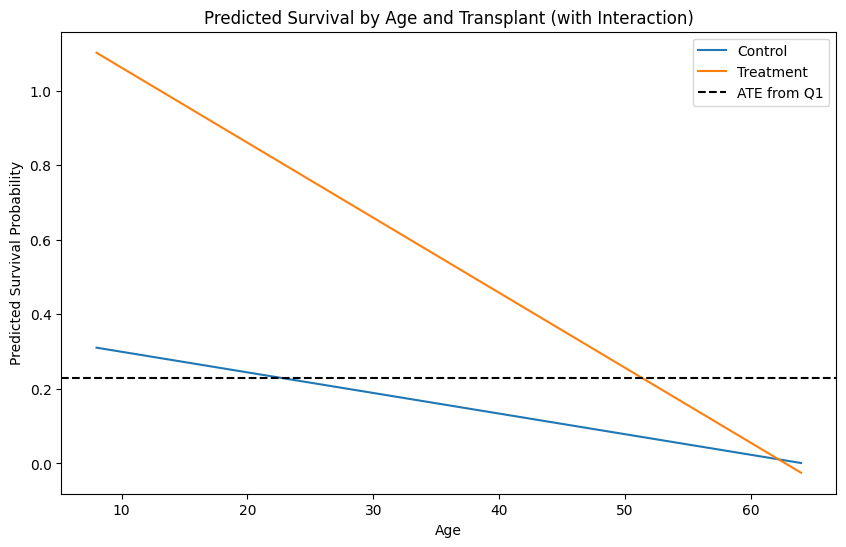

In [25]:
#4

df3['transplant_age'] = df3['transplant_dummy'] * df3['age']

X4 = df3[['transplant_dummy', 'age', 'transplant_age']]
model_q4_interact = LinearRegression()
model_q4_interact.fit(X4, y3)

print("Intercept:", model_q4_interact.intercept_)
print("Transplant coefficient:", model_q4_interact.coef_[0])
print("Age coefficient:", model_q4_interact.coef_[1])
print("Transplant*Age coefficient:", model_q4_interact.coef_[2])

# Plot predicted probabilities by age
age_range = np.linspace(df3['age'].min(), df3['age'].max(), 100)

pred_control = model_q4_interact.predict(np.column_stack([
    np.zeros(100), age_range, np.zeros(100)  # transplant=0, interaction=0
]))
pred_treatment = model_q4_interact.predict(np.column_stack([
    np.ones(100), age_range, age_range  # transplant=1, interaction=1*age
]))

plt.figure(figsize=(10, 6))
plt.plot(age_range, pred_control, label='Control')
plt.plot(age_range, pred_treatment, label='Treatment')
plt.axhline(y=ATE, color='black', linestyle='--', label='ATE from Q1')
plt.xlabel('Age')
plt.ylabel('Predicted Survival Probability')
plt.title('Predicted Survival by Age and Transplant (with Interaction)')
plt.legend()
plt.show()

The lines are no longer parallel and the treatment line has a much steeper negative slope than the control line. This shows that the benefit of a transplant decreases as age increases. For younger patients, the transplant effect is large but for older patients the gap shrinks considerably. The transplant coefficient jumped significantly as well, but it has a different interpretation than before. It now represents the estimated survival benefit of a transplant only at age zero. The actual transplant effect at any given age can be calculated by .9078-(-.0145 * age value). I noticed that now for younger patients, the treatment gap is well above the ATE, so the ATE underestimates the transplant benefit, but for older patients, the gap shrinks below the ATE, so the ATE overestimates the transplant benefit. Right at the end, the model even predicts that the transplant is harmful as can be seen by the treatment line being below the control line.

In [26]:
#5
X1 = df3[['transplant_dummy']]                                    # Part 2: transplant only
X2 = df3[['transplant_dummy', 'age']]                            # Part 3: transplant + age
X3 = df3[['transplant_dummy', 'age', 'transplant_age']]          # Part 4: with interaction

models_q4 = {
    'Transplant only': X1,
    'Transplant + Age': X2,
    'Transplant + Age + Interaction': X3
}

print("10-Fold Cross Validation Results (R² scores):\n")
for name, X in models_q4.items():
    model = LinearRegression()
    scores = cross_val_score(model, X, y3, cv=10, scoring='r2')
    print(f"{name}:")
    print(f"  Mean R²: {scores.mean():.4f}")
    print(f"  Std R²:  {scores.std():.4f}\n")

10-Fold Cross Validation Results (R² scores):

Transplant only:
  Mean R²: -0.4044
  Std R²:  0.5758

Transplant + Age:
  Mean R²: -0.4948
  Std R²:  0.7794

Transplant + Age + Interaction:
  Mean R²: -0.4910
  Std R²:  0.8867



### Question 6
Construction Concerns: The model only uses age and transplant status to predict survival. It ignores many other factors that may play a key role in survival such as overall health, diseases severity, and other medical conditions. The model does not generalize well to new data as can be seen with the negative mean R2 values. Lastly, the data may have selection bias and not represent an equal set from the population.  

Deployment Concerns: Prioritizing transplant access is deeply unfair since age is a key predictor, meaning older patients would systematically be deprived of a transplant even if they could benefit more than a younger person. Due to the severity of the cases (life or death), this model may directly cause harm. As stated, representational bias (bias on race, gender, income, etc) could cause this harm and further cause complications with who gets a transplant and who does not. Ultimately, there are many complications that can arise with this model as it is too narrow to be used for proper predictions in the real world.